In [1]:
from google.colab import drive
import os

# Google Drive'ı bağlayın
drive.mount('/content/drive')

Mounted at /content/drive


## **Resnet50**

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/highgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Number of steps per epoch (to handle limited dataset)
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

# Model creation function with regularization
def create_model(activation='relu', dropout_rate=0.3, learning_rate=1e-4):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-30:]:  # Fine-tune the last 30 layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2, 0.3]
learning_rates = [1e-4, 1e-5]
epochs = 50
early_stopping_patience = 5  # Increased early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=2,
                    min_lr=1e-6
                )

                # Training the model
                history = model.fit(
                    train_generator,
                    steps_per_epoch=steps_per_epoch,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=validation_steps,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=1
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'ResNet50',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: ResNet50, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model ResNet50, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator, steps=validation_steps)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 489 images belonging to 2 classes.
Found 122 images belonging to 2 classes.
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9182 - loss: 8.1595 - val_accuracy: 1.0000 - val_loss: 7.5441 - learning_rate: 1.0000e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 1.0000 - loss: 7.4446 - val_accuracy: 1.0000 - val_loss: 7.5121 - learning_rate: 1.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 261ms/step - accuracy: 1.0000 - loss: 7.1929 - val_accuracy: 1.0000 - val_loss: 6.5644 - learning_rate: 1.0000e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 6.5415 - val_accuracy: 1.0000 - val_loss: 6.5343 - learning_rate: 1.0000e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 1.0000 - loss: 6.3037 - val_accuracy: 1.0000 - val_loss: 5.6881 - learning_rate: 1.0000e-04
Epoch 6/50
30/

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step


ValueError: Found input variables with inconsistent numbers of samples: [122, 112]

# **Vgg16**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2835 images belonging to 2 classes.
Found 707 images belonging to 2 classes.
58889256/58889256 [==============================] - 4s 0us/step
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5355113744735718
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.5795454382896423
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5355113744735718
Model: VGG16, Activation: tanh, Dropout Ra

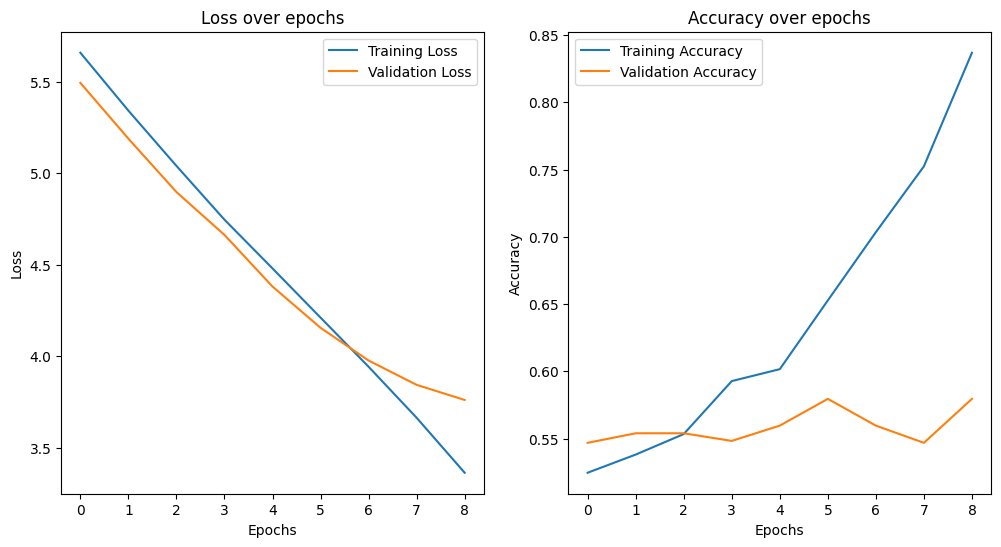

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/lowgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-4:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'VGG16',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: VGG16, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model VGG16, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **inceptionv3**


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2835 images belonging to 2 classes.
Found 707 images belonging to 2 classes.
87910968/87910968 [==============================] - 5s 0us/step
Model: InceptionV3, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5014204382896423
Model: InceptionV3, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5397727489471436
Model: InceptionV3, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.5227272510528564
Model: InceptionV3, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.5326704382896423
Model: InceptionV3, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.4943181872367859
Model: InceptionV3, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5440340638160706
Model:

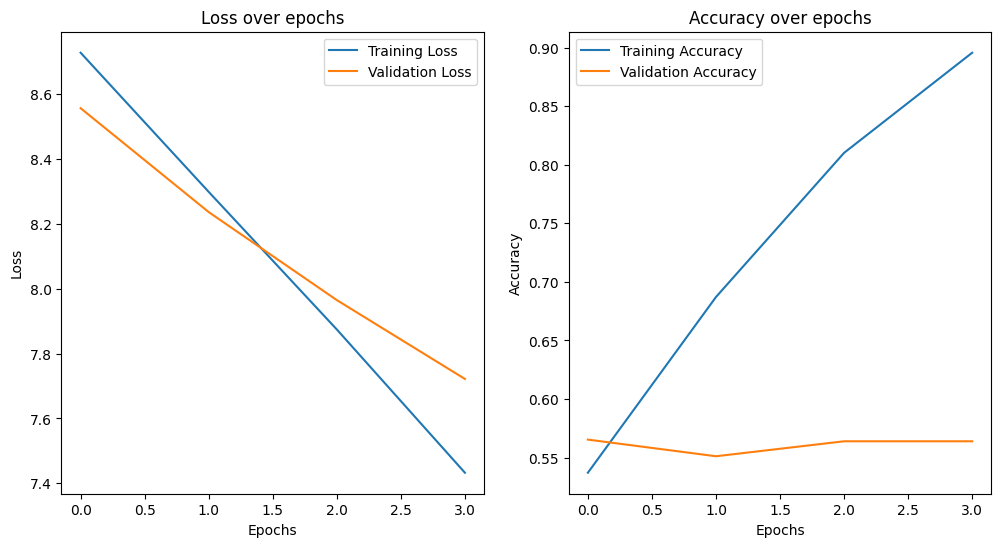

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/lowgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-30:]:  # Fine-tune the last 30 layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'InceptionV3',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: InceptionV3, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model InceptionV3, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **Nasnetmobike**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2835 images belonging to 2 classes.
Found 707 images belonging to 2 classes.
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5397727489471436
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5298295617103577
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.4943181872367859
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.3333333432674408
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.5525568127632141
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5127840638160706
Model: NASNetMobile, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5369318127632141
Model: NASNetMobile, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5482954382896423
Model: NASNetMobile, Activation: tan

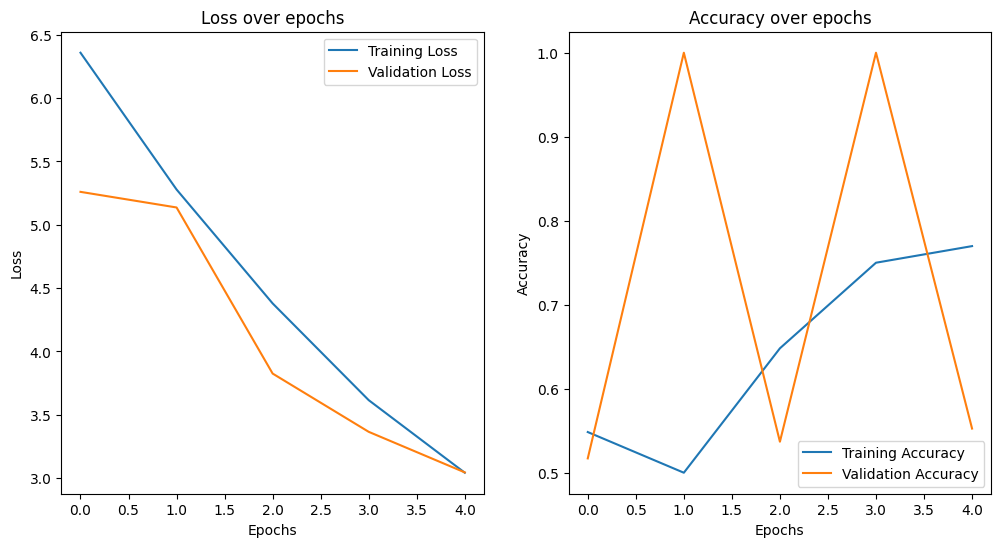

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/lowgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-4:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'NASNetMobile',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: NASNetMobile, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model NASNetMobile, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **Vgg19**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2835 images belonging to 2 classes.
Found 707 images belonging to 2 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5525568127632141
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.5539772510528564
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5525568127632141
Model: VGG19, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: VGG19, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.546875
Model: VGG19, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.53835

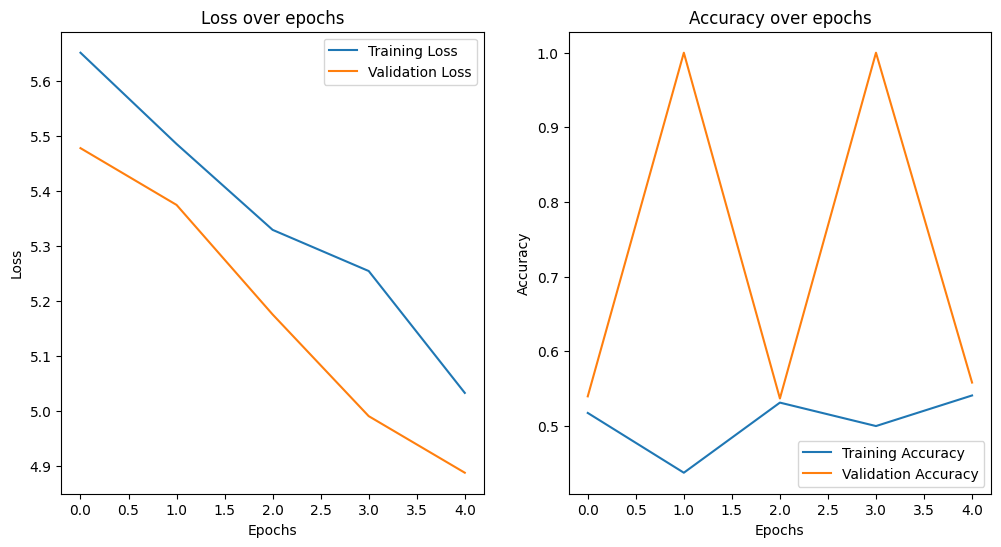

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/lowgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-4:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'VGG19',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: VGG19, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model VGG19, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **EFficentb0**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2835 images belonging to 2 classes.
Found 707 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5056818127632141
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.5383522510528564
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.46022728085517883
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.53125
Model: EfficientNetB0, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5525568127632141
Model: EfficientNetB0, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 

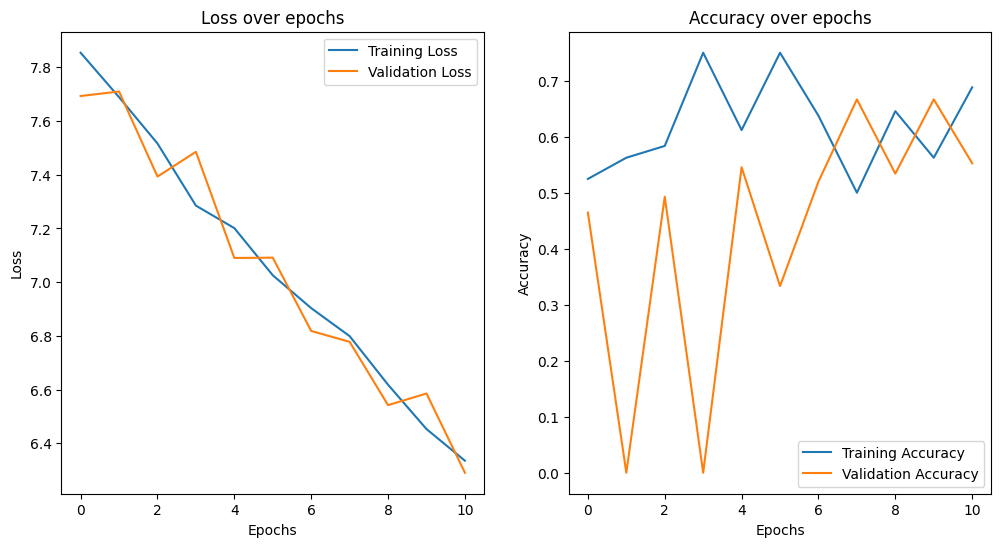

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/lowgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-10:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'EfficientNetB0',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: EfficientNetB0, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model EfficientNetB0, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **Densenet169**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2835 images belonging to 2 classes.
Found 707 images belonging to 2 classes.
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: DenseNet169, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5539772510528564
Model: DenseNet169, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5340909361839294
Model: DenseNet169, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.4943181872367859
Model: DenseNet169, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.5639204382896423
Model: DenseNet169, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.5355113744735718
Model: DenseNet169, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5539772510528564
Model: DenseNet169, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.546875
Model: DenseNet169, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5440340638160706
Model: DenseNet169, Activation: tanh, Dropout Rate: 0.

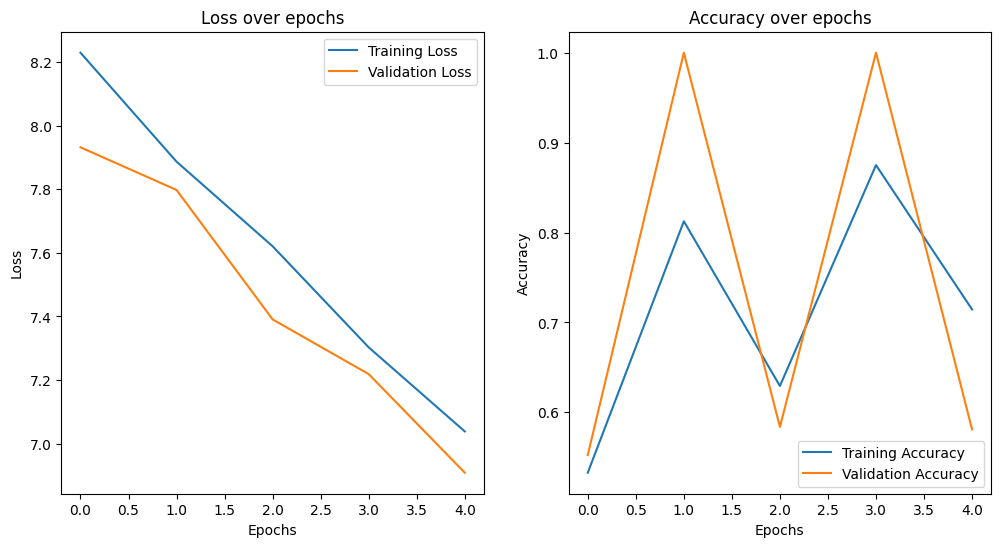

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/lowgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-10:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'DenseNet169',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: DenseNet169, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model DenseNet169, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **Mobilenetv2**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2835 images belonging to 2 classes.
Found 707 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5397727489471436
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.53125
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.4829545319080353
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.5198863744735718
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.5511363744735718
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.3333333432674408
Model: MobileNetV2, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: MobileNetV2, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5497159361839294
Model: MobileNetV2, Activation: tanh, Dropout Rate: 0.1, Learning Rate

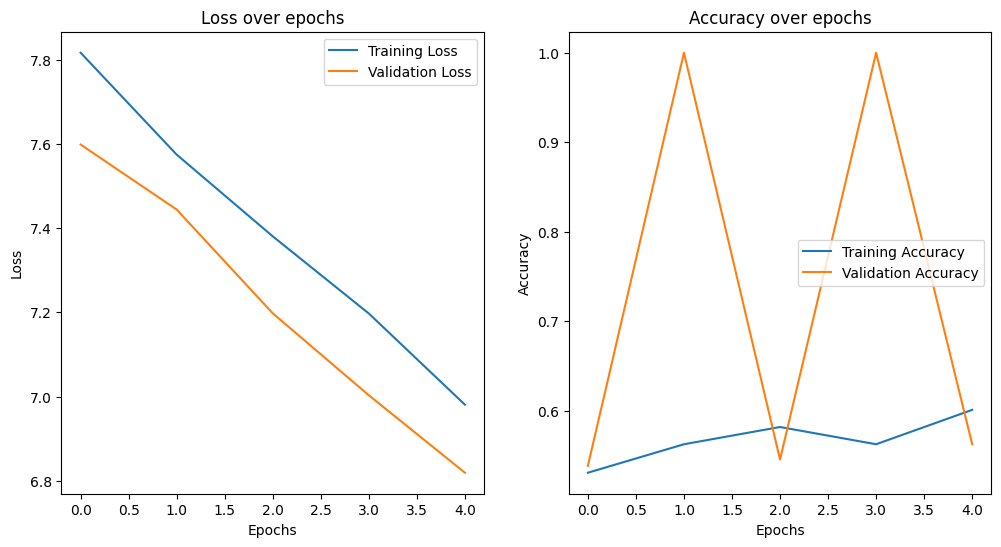

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Graf4o/lowgraf'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v4']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v4']
)

# Model creation function for MobileNetV2
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-10:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'MobileNetV2',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: MobileNetV2, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model MobileNetV2, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
